# 波头 CNN 粗到细全代码版：PyTorch + Google Colab CUDA

这个 Notebook 面向 Google Colab。上传 `wavefront_colab_package.zip` 后，首个单元会自动解压。数据预处理、增强、Residual U-Net、
粗区间分类、区间内偏移、两阶段迁移学习、实时训练面板、验证测试和模型导出全部定义在这里。

**使用顺序**：在 Colab 选择 GPU 运行时，上传同目录生成的 `wavefront_colab_package.zip`，然后运行全部单元。线路长度不进入波头 CNN，它只属于后续故障定位层。

## 1. 环境、路径和总开关

In [2]:
from __future__ import annotations

import json
import math
import os
import platform
import zipfile
import random
import sys
from dataclasses import asdict, dataclass
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import clear_output, display
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

PACKAGE_ZIP = Path("/content/wavefront_colab_package.zip")
EXTRACT_PARENT = Path("/content")
PROJECT_ROOT = EXTRACT_PARENT / "wavefront_colab_package"

if not PACKAGE_ZIP.exists():
    from google.colab import files
    print("请上传 wavefront_colab_package.zip。")
    uploaded = files.upload()
    if "wavefront_colab_package.zip" not in uploaded:
        raise FileNotFoundError("未上传 wavefront_colab_package.zip。")

DATASET_MARKER = PROJECT_ROOT / "data/derived/wavefront_dataset_v1/waveforms.h5"
if not DATASET_MARKER.exists():
    print("开始解压 wavefront_colab_package.zip ...")
    with zipfile.ZipFile(PACKAGE_ZIP, "r") as archive:
        archive.extractall(EXTRACT_PARENT)
    print("解压完成:", PROJECT_ROOT)

DATASET_DIR = PROJECT_ROOT / "data/derived/wavefront_dataset_v1"
OUTPUT_DIR = PROJECT_ROOT / "data/derived/wavefront_cnn_coarse_fine_run"
TRAINING_PROTOCOL = "coarse_fine_v2_colab_cuda"

RUN_CUDA_SMOKE = True
RUN_OVERFIT_SANITY = True
RUN_FULL_TRAINING = True
RUN_FINAL_EVALUATION = True
EXPORT_ONNX = False

assert DATASET_MARKER.exists(), f"数据集不存在: {DATASET_MARKER}"
assert torch.cuda.is_available(), "当前 Colab runtime 未启用 GPU：Runtime > Change runtime type > GPU。"
DEVICE = torch.device("cuda")
torch.backends.cudnn.benchmark = True

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("系统:", platform.platform())
print("项目目录:", PROJECT_ROOT)
print("训练协议:", TRAINING_PROTOCOL)
print("输出目录:", OUTPUT_DIR)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0))
assert OUTPUT_DIR.name == "wavefront_cnn_coarse_fine_run", "拒绝写入旧热力图模型目录。"


开始解压 wavefront_colab_package.zip ...
解压完成: /content/wavefront_colab_package
Python: 3.12.13
PyTorch: 2.11.0+cu128
系统: Linux-6.6.122+-x86_64-with-glibc2.35
项目目录: /content/wavefront_colab_package
训练协议: coarse_fine_v2_colab_cuda
输出目录: /content/wavefront_colab_package/data/derived/wavefront_cnn_coarse_fine_run
CUDA available: True
CUDA device: Tesla T4


## 2. 集中配置

默认使用 FP32，准确率和稳定性优先。若显存不足，首先把 `batch_size` 改为 16。

In [3]:
@dataclass
class Config:
    dataset_dir: str = str(DATASET_DIR)
    output_dir: str = str(OUTPUT_DIR)
    seed: int = 42
    base_channels: int = 32
    bottleneck_dilations: tuple[int, ...] = (1, 2, 4, 8)
    num_bins: int = 256
    batch_size: int = 32
    num_workers: int = 0
    heatmap_sigma: float = 6.0
    max_shift: int = 192
    pretrain_epochs: int = 40
    finetune_epochs: int = 60
    freeze_epochs: int = 5
    pretrain_lr: float = 2e-3
    finetune_lr: float = 5e-4
    weight_decay: float = 1e-4
    patience: int = 10
    sampling_rate_hz: float = 1_250_000.0
    window_samples: int = 8192


config = Config()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
display(pd.Series(asdict(config), name="value").to_frame())


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(config.seed)


def empty_device_cache() -> None:
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


,value
dataset_dir,/content/wavefront_colab_package/data/derived/...
output_dir,/content/wavefront_colab_package/data/derived/...
seed,42
base_channels,32
bottleneck_dilations,"(1, 2, 4, 8)"
num_bins,256
batch_size,32
num_workers,0
heatmap_sigma,6.0
max_shift,192


### 训练配置参数说明

以下是 `Config` 类中定义的各个训练参数及其含义：

- `dataset_dir`: `str`，数据集的根目录，通常指向 `wavefront_dataset_v1`。
- `output_dir`: `str`，模型训练输出（如检查点、历史记录、评估结果）的目录。
- `seed`: `int`，随机种子，用于保证实验的可复现性。
- `base_channels`: `int`，U-Net 编码器中第一层卷积的基准通道数，后续层会在此基础上翻倍。
- `bottleneck_dilations`: `tuple[int, ...]`，瓶颈层中残差块的空洞卷积率，用于扩大感受野而不增加参数。
- `num_bins`: `int`，粗分类阶段将信号窗口划分成的区间数量，每个区间代表一个潜在的波头位置。
- `batch_size`: `int`，每个训练批次的样本数量。
- `num_workers`: `int`，PyTorch `DataLoader` 中用于数据加载的子进程数量。设置为 0 表示在主进程加载。
- `heatmap_sigma`: `float`，用于生成高斯波头监督热图的标准差，控制热图的宽度。
- `max_shift`: `int`，数据增强时允许的最大时间平移量（采样点数），防止波头移出窗口。
- `pretrain_epochs`: `int`，预训练阶段（使用 hard + soft 标签）的训练轮数。
- `finetune_epochs`: `int`，精调阶段（使用 hard 标签，编码器可能冻结）的训练轮数。
- `freeze_epochs`: `int`，精调阶段开始时冻结编码器权重的轮数，有助于模型更好地适应新任务。
- `pretrain_lr`: `float`，预训练阶段的初始学习率。
- `finetune_lr`: `float`，精调阶段的初始学习率。
- `weight_decay`: `float`，优化器中的权重衰减（L2 正则化）系数，用于防止过拟合。
- `patience`: `int`，早停机制的耐心值，表示验证指标连续多少个 epoch 没有改善时停止训练。
- `sampling_rate_hz`: `float`，原始信号的采样率（赫兹），用于将采样点数转换为时间单位。
- `window_samples`: `int`，每个信号窗口的采样点数，即模型的输入长度。

## 3. 数据审计

数据划分必须使用 `split_event`。如果同一事件出现在多个集合，训练会立即停止。

{
  "hdf5_shape": [
    2587,
    3,
    8192
  ],
  "sampling_rate_hz": 1250000.0,
  "window_samples": 8192,
  "valid_hard": 4592,
  "valid_soft": 1306,
  "valid_review": 205,
  "event_leakage": 0,
  "hard_phase_spread_gt_64_samples": 226,
  "hard_phase_spread_gt_64_ratio": 0.14780902550686723,
  "position_only_baseline": {
    "train": {
      "median": 3519.0,
      "mae_samples": 556.6647382920111
    },
    "val": {
      "median": 3515.0,
      "mae_samples": 532.0644391408115
    },
    "test": {
      "median": 3597.0,
      "mae_samples": 551.3738489871087
    }
  }
}


split_event,test,train,val,All
label_status,,,,
hard,543,3630,419,4592
review,16,165,24,205
soft,129,1086,91,1306
All,688,4881,534,6103


注意: hard 只表示多检测器伪标签一致，不等于经人工核验的物理真值。


/tmp/ipykernel_478/3236851511.py:52: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/3236851511.py:52: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/3236851511.py:52: UserWarning: Glyph 20869 (\N{CJK UNIFIED IDEOGRAPH-5185}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/3236851511.py:52: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/3236851511.py:52: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/3236851511.py:52: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/3236851511.py:52: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missi

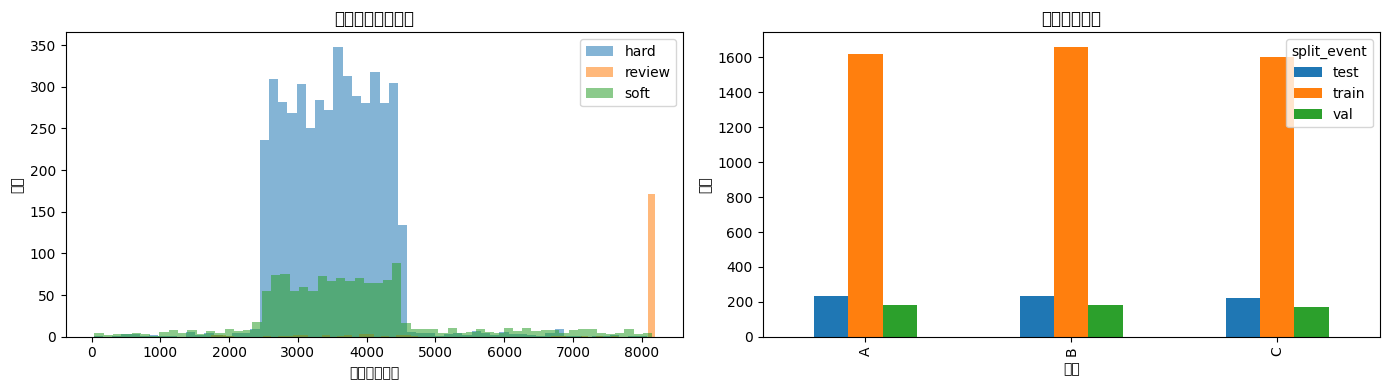

In [4]:
labels_table = pd.read_csv(DATASET_DIR / "phase_labels.csv")
manifest_table = pd.read_csv(DATASET_DIR / "manifest.csv")
with h5py.File(DATASET_DIR / "waveforms.h5", "r") as handle:
    h5_shape = handle["signals"].shape
    h5_sampling_rate = float(handle.attrs["target_sampling_rate_hz"])
    h5_window_samples = int(handle.attrs["window_samples"])

valid_labels = labels_table[labels_table.window_wavefront_index >= 0].copy()
hard_labels = valid_labels[valid_labels.label_status == "hard"].copy()
event_split_count = manifest_table.groupby("event_key").split_event.nunique()
leaking_events = int((event_split_count > 1).sum())

hard_phase_spread = hard_labels.groupby("sample_index").window_wavefront_index.agg(
    lambda values: float(values.max() - values.min()) if len(values) >= 2 else np.nan
).dropna()
position_prior = {}
for split in ("train", "val", "test"):
    positions = hard_labels.loc[hard_labels.split_event == split, "window_wavefront_index"].to_numpy()
    median = float(np.median(positions))
    position_prior[split] = {
        "median": median,
        "mae_samples": float(np.mean(np.abs(positions - median))),
    }

audit = {
    "hdf5_shape": h5_shape,
    "sampling_rate_hz": h5_sampling_rate,
    "window_samples": h5_window_samples,
    "valid_hard": int((valid_labels.label_status == "hard").sum()),
    "valid_soft": int((valid_labels.label_status == "soft").sum()),
    "valid_review": int((valid_labels.label_status == "review").sum()),
    "event_leakage": leaking_events,
    "hard_phase_spread_gt_64_samples": int((hard_phase_spread > 64).sum()),
    "hard_phase_spread_gt_64_ratio": float((hard_phase_spread > 64).mean()),
    "position_only_baseline": position_prior,
}
print(json.dumps(audit, ensure_ascii=False, indent=2))
display(pd.crosstab(valid_labels.label_status, valid_labels.split_event, margins=True))
assert h5_shape == (2587, 3, 8192)
assert h5_sampling_rate == config.sampling_rate_hz
assert leaking_events == 0
assert audit["valid_hard"] == 4592
print("注意: hard 只表示多检测器伪标签一致，不等于经人工核验的物理真值。")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for label_status, group in valid_labels.groupby("label_status"):
    axes[0].hist(group.window_wavefront_index, bins=60, alpha=0.55, label=label_status)
axes[0].set(title="波头标签位置分布", xlabel="窗口内采样点", ylabel="数量")
axes[0].legend()
pd.crosstab(valid_labels.phase, valid_labels.split_event).plot.bar(ax=axes[1])
axes[1].set(title="各相数据划分", xlabel="相别", ylabel="数量")
plt.tight_layout()
plt.show()


## 4. 数据预处理、增强和 DataLoader

每个文件拆成 A/B/C 三个单相样本。训练增强包括同步时间平移、幅值缩放、极性翻转、
白噪声和基线漂移。标签与波形同步平移，验证和测试不做随机增强。

In [5]:
PHASE_TO_INDEX = {"A": 0, "B": 1, "C": 2}
STATUS_WEIGHT = {"hard": 1.0, "soft": 0.5}


def build_phase_index(split: str, statuses: tuple[str, ...]) -> pd.DataFrame:
    selected = labels_table.loc[
        (labels_table.split_event == split)
        & labels_table.label_status.isin(statuses)
        & (labels_table.window_wavefront_index >= 0)
        & labels_table.phase.isin(PHASE_TO_INDEX)
    ].copy()
    selected["sample_index"] = selected.sample_index.astype(np.int64)
    selected["window_wavefront_index"] = selected.window_wavefront_index.astype(np.float32)
    return selected.reset_index(drop=True)


def gaussian_heatmap(length: int, center: float, sigma: float) -> np.ndarray:
    positions = np.arange(length, dtype=np.float32)
    return np.exp(-0.5 * ((positions - np.float32(center)) / np.float32(sigma)) ** 2).astype(np.float32)


def shift_signal(signal: np.ndarray, coordinate: float, shift: int) -> tuple[np.ndarray, float]:
    shifted = np.zeros_like(signal)
    if shift > 0:
        shifted[shift:] = signal[:-shift]
    elif shift < 0:
        shifted[:shift] = signal[-shift:]
    else:
        shifted[:] = signal
    return shifted, float(coordinate + shift)


class WavefrontDataset(Dataset):
    def __init__(self, index: pd.DataFrame, augment: bool, cfg: Config):
        self.index = index.reset_index(drop=True)
        self.augment = augment
        self.cfg = cfg
        self.h5_path = str(Path(cfg.dataset_dir) / "waveforms.h5")
        self._h5 = None
        self._pid = None

    def __len__(self) -> int:
        return len(self.index)

    def _handle(self):
        pid = os.getpid()
        if self._h5 is None or self._pid != pid:
            if self._h5 is not None:
                self._h5.close()
            self._h5 = h5py.File(self.h5_path, "r", swmr=True)
            self._pid = pid
        return self._h5

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_h5"] = None
        state["_pid"] = None
        return state

    def _augment(self, signal: np.ndarray, coordinate: float) -> tuple[np.ndarray, float]:
        lower = max(-self.cfg.max_shift, int(np.ceil(-coordinate)))
        upper = min(self.cfg.max_shift, int(np.floor(self.cfg.window_samples - 1 - coordinate)))
        shift = int(np.random.randint(lower, upper + 1))
        signal, coordinate = shift_signal(signal, coordinate, shift)
        gain = np.random.uniform(0.75, 1.25)
        polarity = -1.0 if np.random.random() < 0.5 else 1.0
        signal *= np.float32(gain * polarity)
        signal += np.random.normal(0, 0.025, signal.size).astype(np.float32)
        slope = np.random.normal(0, 0.02)
        signal += np.linspace(-slope, slope, signal.size, dtype=np.float32)
        return signal, coordinate

    def __getitem__(self, item: int) -> dict:
        row = self.index.iloc[item]
        phase_index = PHASE_TO_INDEX[str(row.phase)]
        signal = np.asarray(
            self._handle()["signals"][int(row.sample_index), phase_index, :], dtype=np.float32
        ).copy()
        coordinate = float(row.window_wavefront_index)
        if self.augment:
            signal, coordinate = self._augment(signal, coordinate)
        target = gaussian_heatmap(self.cfg.window_samples, coordinate, self.cfg.heatmap_sigma)
        return {
            "signal": torch.from_numpy(signal[None, :]),
            "target": torch.from_numpy(target[None, :]),
            "coordinate": torch.tensor(coordinate, dtype=torch.float32),
            "sample_weight": torch.tensor(STATUS_WEIGHT[str(row.label_status)], dtype=torch.float32),
            "sample_id": f"{row.sample_id}:{row.phase}",
            "sample_index": int(row.sample_index),
            "phase": str(row.phase),
            "label_status": str(row.label_status),
        }


def create_loaders(statuses: tuple[str, ...], seed: int) -> dict[str, DataLoader]:
    generator = torch.Generator().manual_seed(seed)
    loaders = {}
    for split in ("train", "val", "test"):
        dataset = WavefrontDataset(build_phase_index(split, statuses), split == "train", config)
        loaders[split] = DataLoader(
            dataset,
            batch_size=config.batch_size,
            shuffle=split == "train",
            num_workers=config.num_workers,
            persistent_workers=config.num_workers > 0,
            generator=generator if split == "train" else None,
        )
    return loaders


### 预处理可视化：原始样本与增强样本

/tmp/ipykernel_478/618584560.py:18: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/618584560.py:18: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/618584560.py:18: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/618584560.py:18: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/618584560.py:18: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/618584560.py:18: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/618584560.py:18: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from

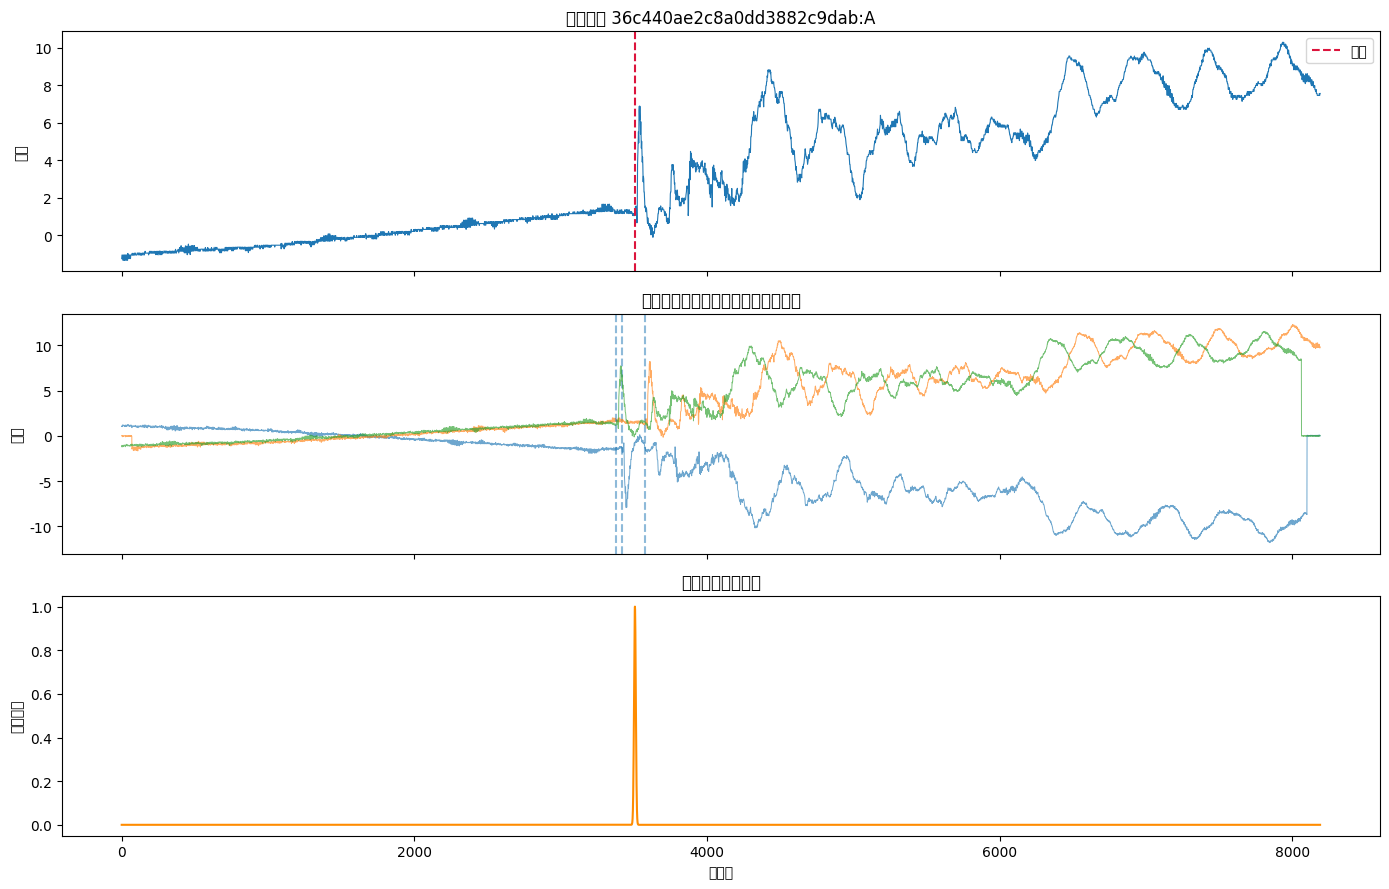

In [6]:
preview_index = build_phase_index("train", ("hard",))
plain_dataset = WavefrontDataset(preview_index.iloc[:8], False, config)
augmented_dataset = WavefrontDataset(preview_index.iloc[:8], True, config)
plain = plain_dataset[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(plain["signal"].squeeze().numpy(), linewidth=0.8)
axes[0].axvline(float(plain["coordinate"]), color="crimson", linestyle="--", label="波头")
axes[0].set(title=f"原始样本 {plain['sample_id']}", ylabel="幅值")
axes[0].legend()
for index in range(3):
    augmented = augmented_dataset[0]
    axes[1].plot(augmented["signal"].squeeze().numpy(), alpha=0.65, linewidth=0.7)
    axes[1].axvline(float(augmented["coordinate"]), alpha=0.5, linestyle="--")
axes[1].set(title="三次随机增强，竖线与波形同步平移", ylabel="幅值")
axes[2].plot(plain["target"].squeeze().numpy(), color="darkorange")
axes[2].set(title="高斯波头监督热图", xlabel="采样点", ylabel="目标概率")
plt.tight_layout()
plt.show()


## 5. 粗到细波头网络

编码器通道为 32、64、128、256，瓶颈空洞率为 1、2、4、8。网络先用 256 类
softmax 选择 32 点区间，再回归该区间中心附近的偏移。分类 argmax 与最终推理完全一致，
同时彻底移除产生左边界伪峰的转置卷积。

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, dilation: int = 1):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 3, stride=stride, padding=dilation,
                      dilation=dilation, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.SiLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, 3, padding=dilation,
                      dilation=dilation, bias=False),
            nn.BatchNorm1d(out_channels),
        )
        self.skip = nn.Identity() if in_channels == out_channels and stride == 1 else nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 1, stride=stride, bias=False),
            nn.BatchNorm1d(out_channels),
        )
        self.activation = nn.SiLU(inplace=True)

    def forward(self, x):
        return self.activation(self.main(x) + self.skip(x))


class CoarseFineWavefrontNet(nn.Module):
    def __init__(self, base_channels: int = 32, num_bins: int = 256,
                 window_samples: int = 8192, dilations: tuple[int, ...] = (1, 2, 4, 8)):
        super().__init__()
        if window_samples % num_bins != 0:
            raise ValueError("window_samples 必须能被 num_bins 整除。")
        c1, c2, c3, c4 = base_channels, base_channels * 2, base_channels * 4, base_channels * 8
        self.num_bins = num_bins
        self.window_samples = window_samples
        self.offset_limit = (window_samples / num_bins - 1) / 2
        self.stem = nn.Sequential(
            nn.Conv1d(1, c1, 7, padding=3, bias=False), nn.BatchNorm1d(c1), nn.SiLU(inplace=True)
        )
        self.encoder1 = ResidualBlock(c1, c2, stride=2)
        self.encoder2 = ResidualBlock(c2, c3, stride=2)
        self.encoder3 = ResidualBlock(c3, c4, stride=2)
        self.bottleneck = nn.Sequential(*(ResidualBlock(c4, c4, dilation=d) for d in dilations))
        self.bin_pool = nn.AdaptiveAvgPool1d(num_bins)
        self.coarse_head = nn.Conv1d(c4, 1, 1)
        self.offset_head = nn.Conv1d(c4, 1, 1)

    def forward(self, x):
        features = self.stem(x)
        features = self.encoder1(features)
        features = self.encoder2(features)
        features = self.encoder3(features)
        features = self.bin_pool(self.bottleneck(features))
        coarse_logits = self.coarse_head(features).squeeze(1)
        raw_offsets = self.offset_head(features).squeeze(1)
        offsets = torch.tanh(raw_offsets / self.offset_limit) * self.offset_limit
        return coarse_logits, offsets


model = CoarseFineWavefrontNet(
    config.base_channels, config.num_bins, config.window_samples, config.bottleneck_dilations
).to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"模型参数量: {parameter_count:,}")
test_logits, test_offsets = model(torch.randn(2, 1, config.window_samples, device=DEVICE))
print("区间 logits/偏移形状:", tuple(test_logits.shape), tuple(test_offsets.shape))
assert test_logits.shape == test_offsets.shape == (2, config.num_bins)
del test_logits, test_offsets
empty_device_cache()


模型参数量: 2,010,530
区间 logits/偏移形状: (2, 256) (2, 256)


## 6. 与 argmax 对齐的分类、偏移损失和指标

归一化高斯 softmax 交叉熵迫使概率质量集中到真实区间，避免全低、宽而平的热图。
偏移 Huber 只监督真实区间；最终坐标直接使用 argmax 区间及该区间偏移。

In [8]:
class CoarseFineLoss(nn.Module):
    def __init__(self, num_bins: int = 256, bin_sigma: float = 0.35):
        super().__init__()
        self.num_bins = num_bins
        self.bin_width = config.window_samples / num_bins
        self.bin_sigma = bin_sigma

    def forward(self, logits, offsets, coordinate, sample_weight):
        positions = torch.arange(self.num_bins, device=logits.device, dtype=logits.dtype)
        continuous_bin = coordinate / self.bin_width - 0.5
        target_distribution = torch.exp(
            -0.5 * ((positions[None, :] - continuous_bin[:, None]) / self.bin_sigma) ** 2
        )
        target_distribution /= target_distribution.sum(-1, keepdim=True).clamp_min(1e-12)
        classification = -(target_distribution * torch.log_softmax(logits, -1)).sum(-1)
        true_bin = torch.floor(coordinate / self.bin_width).long().clamp(0, self.num_bins - 1)
        batch = torch.arange(logits.shape[0], device=logits.device)
        center = (true_bin.to(coordinate.dtype) + 0.5) * self.bin_width - 0.5
        true_offset = coordinate - center
        offset_loss = F.smooth_l1_loss(
            offsets[batch, true_bin], true_offset, reduction="none", beta=1.0
        ) / (self.bin_width / 2)
        probabilities = torch.softmax(logits, -1)
        bin_centers = (positions + 0.5) * self.bin_width - 0.5
        expected = (probabilities * (bin_centers[None, :] + offsets)).sum(-1)
        coordinate_loss = F.smooth_l1_loss(
            expected, coordinate, reduction="none", beta=self.bin_width
        ) / self.bin_width
        per_sample = classification + 0.75 * offset_loss + 0.05 * coordinate_loss
        return (per_sample * sample_weight).sum() / sample_weight.sum().clamp_min(1e-6)


def decode_coarse_fine(logits: torch.Tensor, offsets: torch.Tensor) -> torch.Tensor:
    bin_width = config.window_samples / logits.shape[-1]
    selected_bin = logits.argmax(-1)
    batch = torch.arange(logits.shape[0], device=logits.device)
    center = (selected_bin.to(logits.dtype) + 0.5) * bin_width - 0.5
    return center + offsets[batch, selected_bin]


def calculate_metrics(predicted: torch.Tensor, target: torch.Tensor) -> dict:
    error = (predicted.float().cpu() - target.float().cpu()).abs()
    p95_index = min(math.ceil(0.95 * error.numel()) - 1, error.numel() - 1)
    p95 = error.sort().values[p95_index]
    result = {
        "count": int(error.numel()),
        "mae_samples": float(error.mean()),
        "rmse_samples": float(torch.sqrt((error**2).mean())),
        "p95_samples": float(p95),
        "mae_us": float(error.mean()) * 1e6 / config.sampling_rate_hz,
        "p95_us": float(p95) * 1e6 / config.sampling_rate_hz,
    }
    for tolerance in (1, 2, 4, 8, 16):
        result[f"within_{tolerance}_samples"] = float((error <= tolerance).float().mean())
    return result


## 7. 单轮训练、冻结策略和检查点

In [9]:
ENCODER_NAMES = ("stem", "encoder1", "encoder2", "encoder3")


def freeze_encoder(network: nn.Module, frozen: bool) -> None:
    for name in ENCODER_NAMES:
        for parameter in getattr(network, name).parameters():
            parameter.requires_grad = not frozen


def keep_frozen_batchnorm_fixed(network: nn.Module) -> None:
    for name in ENCODER_NAMES:
        module = getattr(network, name)
        if not any(parameter.requires_grad for parameter in module.parameters()):
            module.eval()


def run_epoch(network, loader, criterion, optimizer=None, max_batches=None, collect_rows=False):
    training = optimizer is not None
    network.train(training)
    if training:
        keep_frozen_batchnorm_fixed(network)
    losses, predictions, targets, rows = [], [], [], []

    context = torch.enable_grad() if training else torch.inference_mode()
    with context:
        for batch_index, batch in enumerate(loader):
            if max_batches is not None and batch_index >= max_batches:
                break
            signal = batch["signal"].to(DEVICE)
            coordinate = batch["coordinate"].to(DEVICE)
            weight = batch["sample_weight"].to(DEVICE)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits, offsets = network(signal)
            loss = criterion(logits, offsets, coordinate, weight)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(network.parameters(), 5.0)
                optimizer.step()
            predicted = decode_coarse_fine(logits.detach(), offsets.detach())
            losses.append(float(loss.detach().cpu()))
            predictions.append(predicted.cpu())
            targets.append(coordinate.detach().cpu())
            if collect_rows:
                for index in range(len(batch["sample_id"])):
                    pred = float(predicted[index].cpu())
                    truth = float(coordinate[index].cpu())
                    rows.append({
                        "sample_id": batch["sample_id"][index],
                        "sample_index": int(batch["sample_index"][index]),
                        "phase": batch["phase"][index],
                        "label_status": batch["label_status"][index],
                        "predicted_index": pred,
                        "target_index": truth,
                        "absolute_error_samples": abs(pred - truth),
                    })
    metrics = calculate_metrics(torch.cat(predictions), torch.cat(targets))
    metrics["loss"] = sum(losses) / len(losses)
    return metrics, rows


def save_checkpoint(path: Path, network, optimizer, epoch, best_mae, stage):
    torch.save({
        "model": network.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
        "best_mae": best_mae,
        "stage": stage,
        "config": asdict(config),
    }, path)


def load_checkpoint(path: Path, network, optimizer=None):
    state = torch.load(path, map_location=DEVICE, weights_only=False)
    network.load_state_dict(state["model"])
    if optimizer is not None and state.get("optimizer") is not None:
        optimizer.load_state_dict(state["optimizer"])
    return state


## 8. 实时训练面板

每个 epoch 会刷新以下四部分：损失、MAE/P95、学习率、固定验证样本真实/预测位置。
同一画面保存为 `training_dashboard.png`。

In [10]:
def render_training_dashboard(history: list[dict], network, validation_batch, stage: str) -> None:
    history_frame = pd.DataFrame(history)
    network.eval()
    with torch.inference_mode():
        signal = validation_batch["signal"].to(DEVICE)
        coarse_logits, offsets = network(signal)
        predicted = decode_coarse_fine(coarse_logits, offsets).cpu()

    clear_output(wait=True)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    for current_stage, group in history_frame.groupby("stage"):
        axes[0, 0].plot(group.epoch, group.train_loss, label=f"{current_stage} train")
        axes[0, 0].plot(group.epoch, group.val_loss, "--", label=f"{current_stage} val")
        axes[0, 1].plot(group.epoch, group.val_mae_samples, label=f"{current_stage} MAE")
        axes[0, 1].plot(group.epoch, group.val_p95_samples, "--", label=f"{current_stage} P95")
        axes[1, 0].plot(group.epoch, group.learning_rate, label=current_stage)
    axes[0, 0].set(title="训练与验证损失", xlabel="epoch", ylabel="loss")
    axes[0, 1].set(title="验证集坐标误差", xlabel="epoch", ylabel="采样点")
    axes[1, 0].set(title="学习率", xlabel="epoch", ylabel="learning rate")
    for axis in (axes[0, 0], axes[0, 1], axes[1, 0]):
        axis.legend(); axis.grid(alpha=0.25)

    for index in range(min(3, signal.shape[0])):
        waveform = signal[index, 0].cpu().numpy()
        true_index = float(validation_batch["coordinate"][index])
        axes[1, 1].plot(waveform + index * 5, linewidth=0.6, alpha=0.8)
        axes[1, 1].axvline(true_index, color="green", alpha=0.5)
        axes[1, 1].axvline(float(predicted[index]), color="crimson", linestyle="--", alpha=0.7)
    axes[1, 1].set(
        title="固定验证样本：绿色=标签，红色虚线=预测",
        xlabel="采样点", ylabel="错位显示的波形"
    )
    fig.suptitle(f"波头 CNN 实时训练面板 | 当前阶段: {stage}", fontsize=15)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "training_dashboard.png", dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    latest = history_frame.iloc[-1]
    print(
        f"stage={stage} epoch={int(latest.epoch)} "
        f"train_loss={latest.train_loss:.4f} val_loss={latest.val_loss:.4f} "
        f"val_mae={latest.val_mae_samples:.2f} val_p95={latest.val_p95_samples:.2f} samples"
    )


def fit_stage(stage, network, loaders, epochs, learning_rate, history, freeze_epochs=0):
    criterion = CoarseFineLoss()
    optimizer = torch.optim.AdamW(network.parameters(), lr=learning_rate, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )
    best_path = OUTPUT_DIR / f"best_{stage}.pt"
    last_path = OUTPUT_DIR / f"last_{stage}.pt"
    best_mae, stale_epochs = float("inf"), 0
    validation_batch = next(iter(loaders["val"]))

    for epoch in range(1, epochs + 1):
        if freeze_epochs:
            freeze_encoder(network, epoch <= freeze_epochs)
        train_metrics, _ = run_epoch(network, loaders["train"], criterion, optimizer)
        val_metrics, _ = run_epoch(network, loaders["val"], criterion)
        scheduler.step(val_metrics["mae_samples"])
        history.append({
            "stage": stage,
            "epoch": epoch,
            "learning_rate": optimizer.param_groups[0]["lr"],
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in val_metrics.items()},
        })
        pd.DataFrame(history).to_csv(OUTPUT_DIR / "training_history.csv", index=False)
        save_checkpoint(last_path, network, optimizer, epoch, best_mae, stage)
        if val_metrics["mae_samples"] < best_mae:
            best_mae = val_metrics["mae_samples"]
            stale_epochs = 0
            save_checkpoint(best_path, network, optimizer, epoch, best_mae, stage)
        else:
            stale_epochs += 1
        render_training_dashboard(history, network, validation_batch, stage)
        if stale_epochs >= config.patience:
            print(f"{stage} 触发早停：连续 {config.patience} 个 epoch 未改善。")
            break
    return best_path


## 9. Colab CUDA 单批次自检与训练面板预览

这里只训练一个批次，不代表最终精度。目的是验证真实 HDF5、CUDA 前向、反向和可视化。

/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from

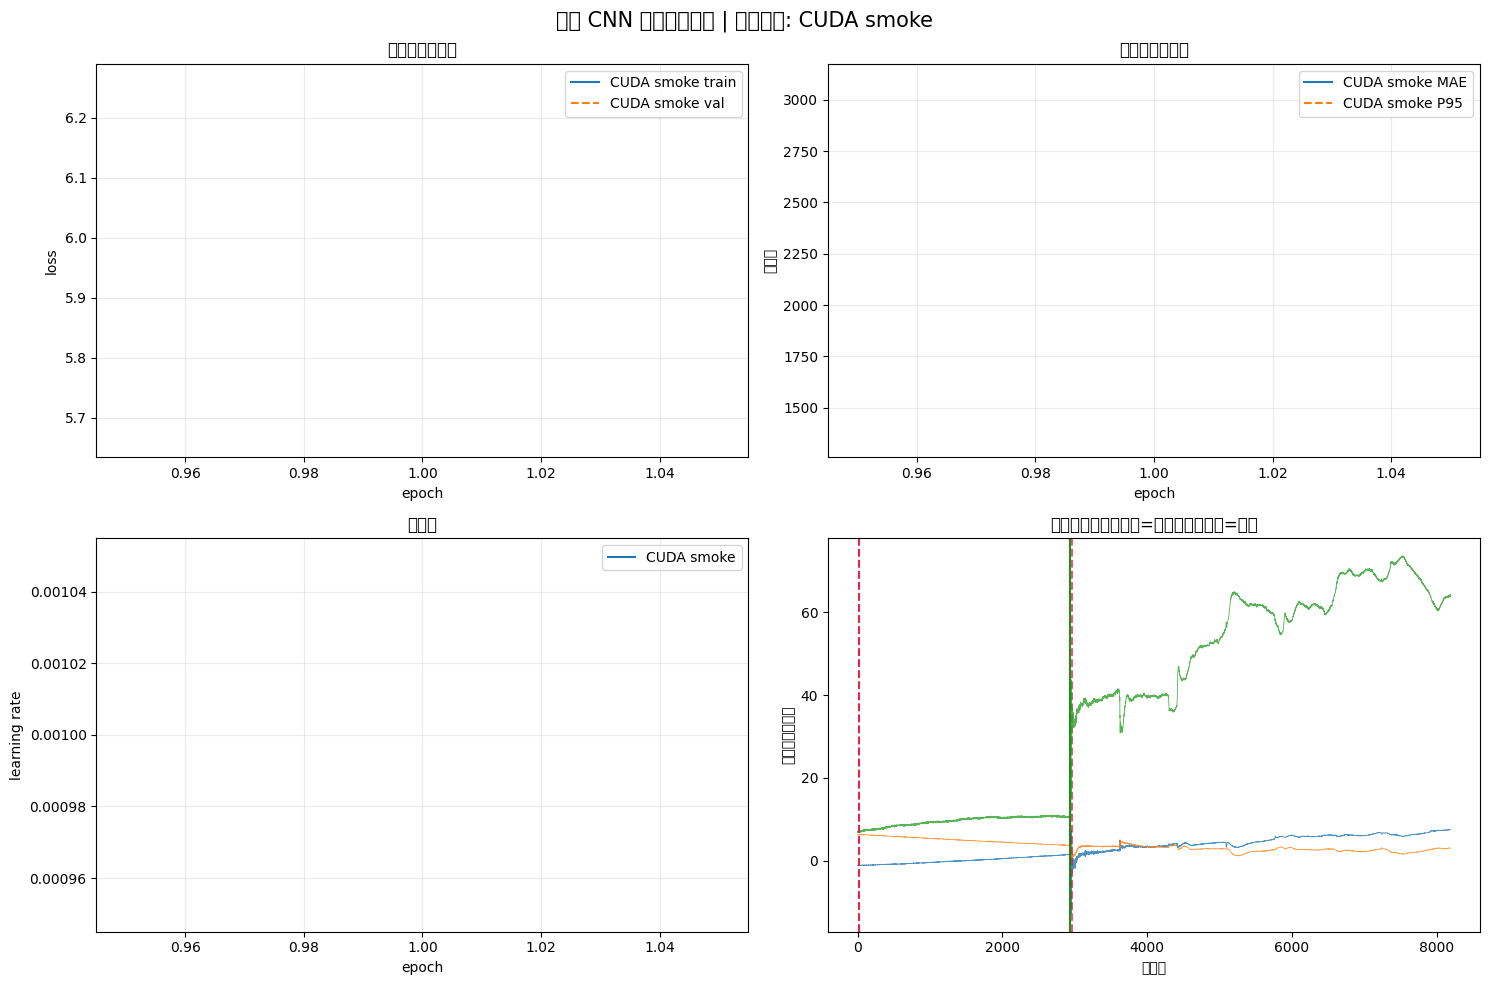

stage=CUDA smoke epoch=1 train_loss=5.9617 val_loss=5.9617 val_mae=1344.55 val_p95=3088.56 samples
CUDA 单批次前向、反向和训练面板均通过。


In [11]:
if RUN_CUDA_SMOKE:
    smoke_config_batch_size = config.batch_size
    config.batch_size = 4
    smoke_loaders = create_loaders(("hard", "soft"), config.seed)
    smoke_model = CoarseFineWavefrontNet(
        base_channels=8, num_bins=config.num_bins,
        window_samples=config.window_samples, dilations=(1, 2)
    ).to(DEVICE)
    smoke_optimizer = torch.optim.AdamW(smoke_model.parameters(), lr=1e-3)
    smoke_metrics, _ = run_epoch(
        smoke_model, [next(iter(smoke_loaders["train"]))], CoarseFineLoss(), smoke_optimizer, max_batches=1
    )
    preview_history = [{
        "stage": "CUDA smoke",
        "epoch": 1,
        "learning_rate": 1e-3,
        **{f"train_{key}": value for key, value in smoke_metrics.items()},
        **{f"val_{key}": value for key, value in smoke_metrics.items()},
    }]
    render_training_dashboard(
        preview_history, smoke_model, next(iter(smoke_loaders["val"])), "CUDA smoke"
    )
    print("CUDA 单批次前向、反向和训练面板均通过。")
    config.batch_size = smoke_config_batch_size
    del smoke_loaders, smoke_model, smoke_optimizer
    empty_device_cache()


## 10. 32 样本无增强过拟合自检

这是全量训练的硬门槛。模型必须在 32 个 hard 样本上达到 MAE 小于 2 点、
`within_4=100%`，否则禁止启动全量训练。

/tmp/ipykernel_478/2011154015.py:36: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/2011154015.py:36: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/2011154015.py:36: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/2011154015.py:36: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/2011154015.py:36: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/2011154015.py:36: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/201115401

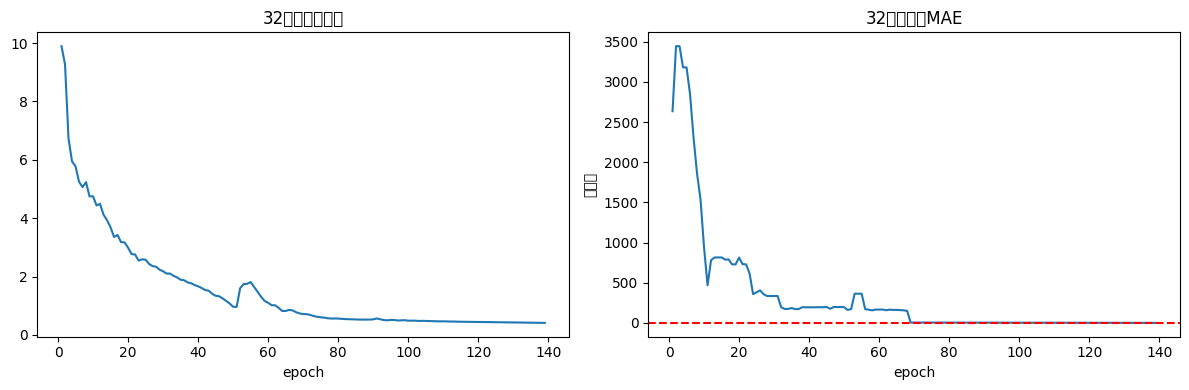

{
  "passed": true,
  "epoch": 139,
  "mae_samples": 0.4611358642578125,
  "within_4_samples": 1.0
}


In [12]:
def run_overfit_sanity(max_epochs: int = 200) -> dict:
    seed_everything(config.seed + 100)
    sanity_index = build_phase_index("train", ("hard",)).iloc[:32].reset_index(drop=True)
    sanity_dataset = WavefrontDataset(sanity_index, False, config)
    sanity_batch = next(iter(DataLoader(sanity_dataset, batch_size=32, shuffle=False)))
    network = CoarseFineWavefrontNet(
        base_channels=8, num_bins=config.num_bins,
        window_samples=config.window_samples, dilations=(1, 2, 4)
    ).to(DEVICE)
    criterion = CoarseFineLoss()
    optimizer = torch.optim.AdamW(network.parameters(), lr=3e-3, weight_decay=0)
    x = sanity_batch["signal"].to(DEVICE)
    y = sanity_batch["coordinate"].to(DEVICE)
    weight = sanity_batch["sample_weight"].to(DEVICE)
    records = []
    for epoch in range(1, max_epochs + 1):
        network.train(); optimizer.zero_grad(set_to_none=True)
        logits, offsets = network(x)
        loss = criterion(logits, offsets, y, weight)
        loss.backward(); optimizer.step()
        network.eval()
        with torch.inference_mode():
            logits, offsets = network(x)
            predicted = decode_coarse_fine(logits, offsets)
            error = (predicted - y).abs()
            mae = float(error.mean().cpu())
            within4 = float((error <= 4).float().mean().cpu())
        records.append({"epoch": epoch, "loss": float(loss.detach().cpu()), "mae": mae})
        if mae < 2 and within4 >= 0.99:
            break
    frame = pd.DataFrame(records)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(frame.epoch, frame.loss); axes[0].set(title="32样本自检损失", xlabel="epoch")
    axes[1].plot(frame.epoch, frame.mae); axes[1].axhline(2, color="red", linestyle="--")
    axes[1].set(title="32样本自检MAE", xlabel="epoch", ylabel="采样点")
    plt.tight_layout(); plt.show()
    report = {"passed": mae < 2 and within4 >= 0.99, "epoch": epoch,
              "mae_samples": mae, "within_4_samples": within4}
    print(json.dumps(report, ensure_ascii=False, indent=2))
    return report


sanity_report = run_overfit_sanity() if RUN_OVERFIT_SANITY else {"passed": False}


## 11. 两阶段迁移学习

阶段一使用 hard+soft；阶段二载入最佳预训练权重，先冻结编码器，再只用 hard 精调。
Colab 版本默认 `RUN_FULL_TRAINING=True`，运行全部单元会直接启动训练。

/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_478/411174375.py:34: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from

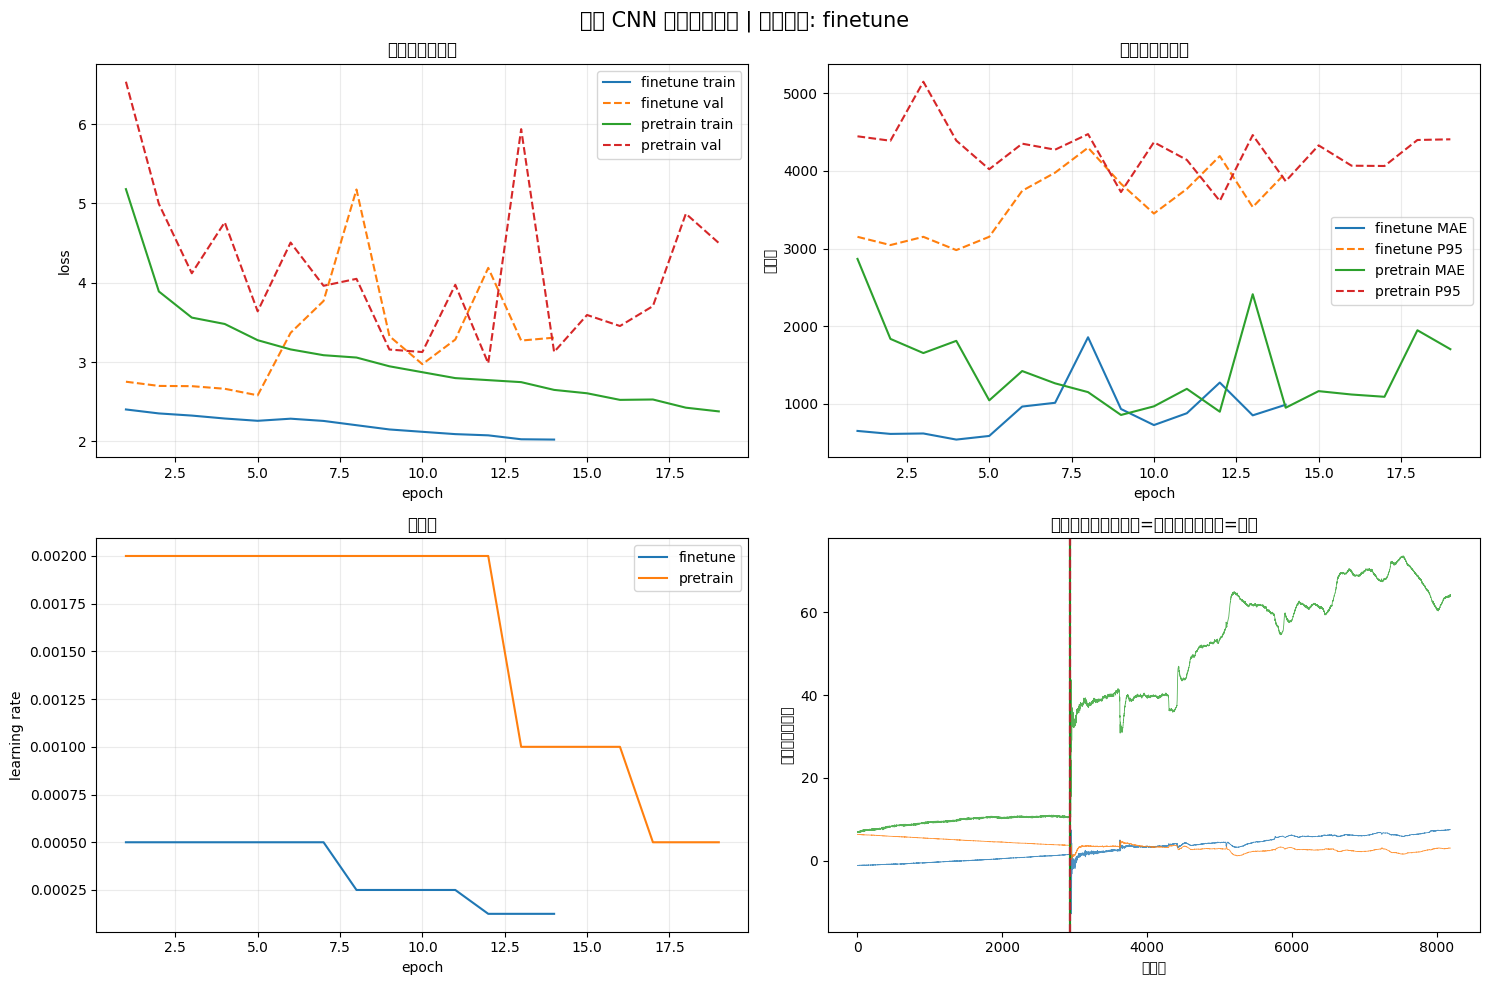

stage=finetune epoch=14 train_loss=2.0229 val_loss=3.3079 val_mae=986.69 val_p95=3975.27 samples
finetune 触发早停：连续 10 个 epoch 未改善。

训练完成！测试集准确率统计:
Within 1 sample error (Acc@1): 18.23%
Within 4 sample error (Acc@4): 48.62%
Within 16 sample error (Acc@16): 64.27%
MAE: 649.90 samples (519.92 us)


In [19]:
def run_two_stage_training():
    assert sanity_report["passed"], "32样本过拟合自检未通过，禁止全量训练。"
    seed_everything(config.seed)

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    network = CoarseFineWavefrontNet(
        config.base_channels, config.num_bins, config.window_samples,
        config.bottleneck_dilations
    ).to(DEVICE)
    history = []

    pretrain_loaders = create_loaders(("hard", "soft"), config.seed)
    pretrain_checkpoint = fit_stage(
        "pretrain", network, pretrain_loaders, config.pretrain_epochs,
        config.pretrain_lr, history, freeze_epochs=0
    )
    load_checkpoint(pretrain_checkpoint, network)

    hard_loaders = create_loaders(("hard",), config.seed + 1)
    finetune_checkpoint = fit_stage(
        "finetune", network, hard_loaders, config.finetune_epochs,
        config.finetune_lr, history, freeze_epochs=config.freeze_epochs
    )
    load_checkpoint(finetune_checkpoint, network)

    test_metrics, test_rows = run_epoch(
        network, hard_loaders["test"], CoarseFineLoss(), collect_rows=True
    )

    pd.DataFrame(test_rows).to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
    report = {
        "device": str(DEVICE),
        "pretrain_checkpoint": str(pretrain_checkpoint),
        "finetune_checkpoint": str(finetune_checkpoint),
        "test_metrics": test_metrics,
        "config": asdict(config),
    }
    (OUTPUT_DIR / "test_metrics.json").write_text(
        json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8"
    )
    return network, pd.DataFrame(history), pd.DataFrame(test_rows), report


if RUN_FULL_TRAINING:
    trained_model, training_history, test_predictions, training_report = run_two_stage_training()
    m = training_report["test_metrics"]
    print(f"\n训练完成！测试集准确率统计:")
    print(f"Within 1 sample error (Acc@1): {m['within_1_samples']:.2%}")
    print(f"Within 4 sample error (Acc@4): {m['within_4_samples']:.2%}")
    print(f"Within 16 sample error (Acc@16): {m['within_16_samples']:.2%}")
    print(f"MAE: {m['mae_samples']:.2f} samples ({m['mae_us']:.2f} us)")
else:
    print("完整训练未启动。设置 RUN_FULL_TRAINING=True 后重新运行本单元。")

## 12. 训练后验证与误差可视化

设置 `RUN_FINAL_EVALUATION=True`。本单元会读取最佳精调权重，绘制误差分布、预测散点和
误差最大的六条波形。

,test
count,543.000000
mae_samples,649.896423
rmse_samples,1358.439209
p95_samples,3313.672363
mae_us,519.917139
p95_us,2650.937891
within_1_samples,0.182320
within_2_samples,0.316759
within_4_samples,0.486188
within_8_samples,0.585635


/tmp/ipykernel_478/3694815039.py:23: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:23: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:23: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:23: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:23: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/369481503

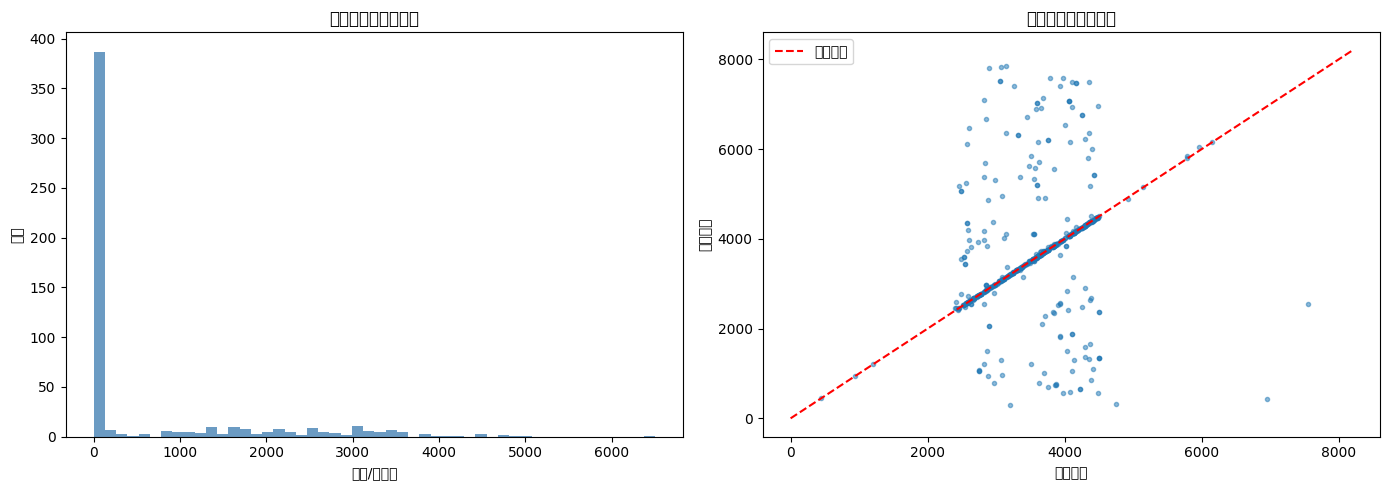

/tmp/ipykernel_478/3694815039.py:38: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:38: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:38: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:38: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:38: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/3694815039.py:38: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/369481503

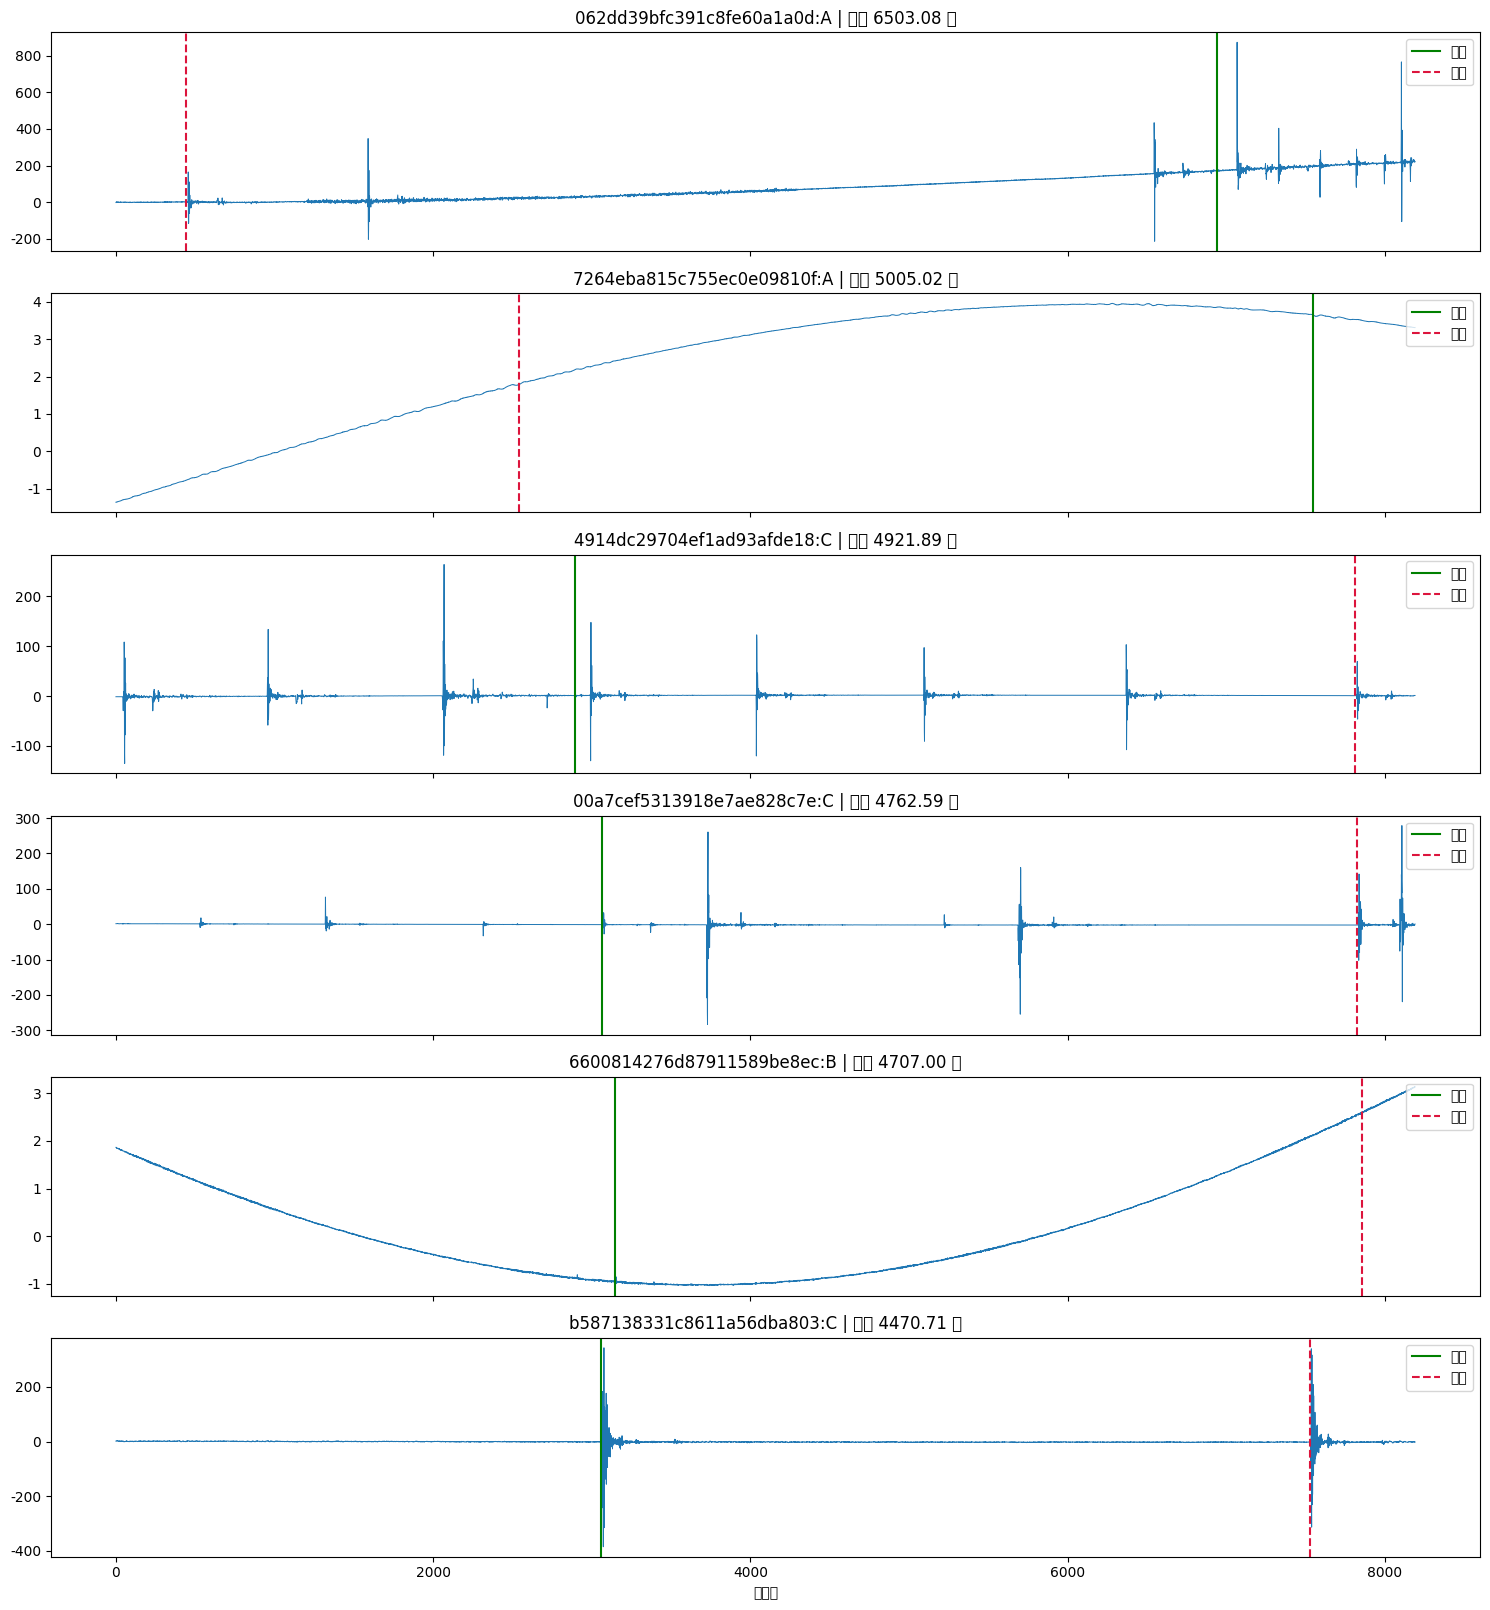

In [20]:
def load_best_model() -> CoarseFineWavefrontNet:
    checkpoint = OUTPUT_DIR / "best_finetune.pt"
    if not checkpoint.exists():
        raise FileNotFoundError("尚未生成 best_finetune.pt，请先完成训练。")
    network = CoarseFineWavefrontNet(
        config.base_channels, config.num_bins, config.window_samples,
        config.bottleneck_dilations
    ).to(DEVICE)
    load_checkpoint(checkpoint, network)
    network.eval()
    return network


def plot_test_analysis(predictions: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(predictions.absolute_error_samples, bins=50, color="steelblue", alpha=0.8)
    axes[0].set(title="测试集绝对误差分布", xlabel="误差/采样点", ylabel="数量")
    axes[1].scatter(predictions.target_index, predictions.predicted_index, s=9, alpha=0.5)
    limits = [0, config.window_samples - 1]
    axes[1].plot(limits, limits, "r--", label="理想预测")
    axes[1].set(title="真实波头与预测波头", xlabel="真实坐标", ylabel="预测坐标")
    axes[1].legend()
    plt.tight_layout(); plt.show()


def plot_worst_cases(predictions: pd.DataFrame, count: int = 6) -> None:
    worst = predictions.nlargest(count, "absolute_error_samples")
    fig, axes = plt.subplots(count, 1, figsize=(15, 2.7 * count), sharex=True)
    with h5py.File(DATASET_DIR / "waveforms.h5", "r") as handle:
        for axis, row in zip(np.atleast_1d(axes), worst.itertuples(), strict=True):
            signal = handle["signals"][int(row.sample_index), PHASE_TO_INDEX[row.phase], :]
            axis.plot(signal, linewidth=0.7)
            axis.axvline(row.target_index, color="green", label="标签")
            axis.axvline(row.predicted_index, color="crimson", linestyle="--", label="预测")
            axis.set_title(f"{row.sample_id} | 误差 {row.absolute_error_samples:.2f} 点")
            axis.legend(loc="upper right")
    axes[-1].set_xlabel("采样点")
    plt.tight_layout(); plt.show()


if RUN_FINAL_EVALUATION:
    evaluation_model = load_best_model()
    hard_loaders = create_loaders(("hard",), config.seed + 1)
    final_metrics, final_rows = run_epoch(
        evaluation_model, hard_loaders["test"], CoarseFineLoss(), collect_rows=True
    )
    final_predictions = pd.DataFrame(final_rows)
    display(pd.Series(final_metrics, name="test").to_frame())
    plot_test_analysis(final_predictions)
    plot_worst_cases(final_predictions)
else:
    print("最终评估未启动。训练完成后设置 RUN_FINAL_EVALUATION=True。")


## 13. 单条波形推理与模型导出

/tmp/ipykernel_478/1199767079.py:22: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/1199767079.py:22: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/1199767079.py:22: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/1199767079.py:22: UserWarning: Glyph 27874 (\N{CJK UNIFIED IDEOGRAPH-6CE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/1199767079.py:22: UserWarning: Glyph 22836 (\N{CJK UNIFIED IDEOGRAPH-5934}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/1199767079.py:22: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_478/119976707

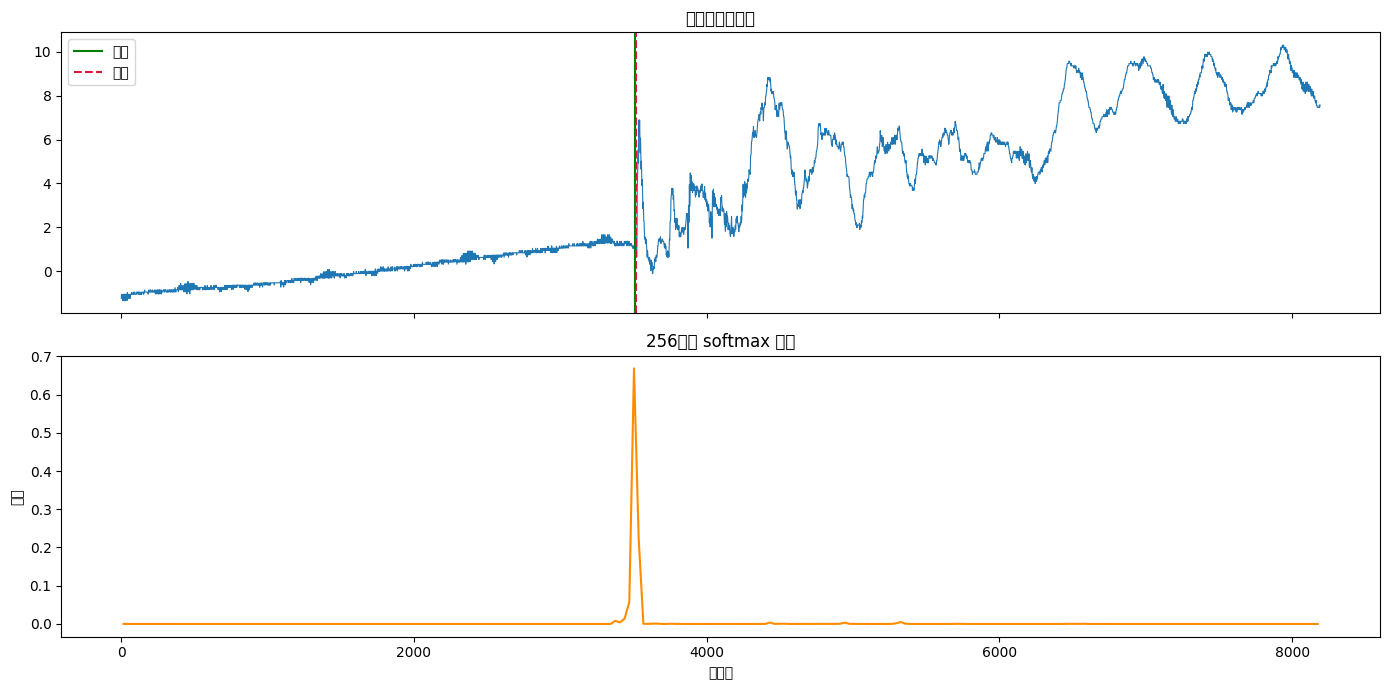

ONNX 未导出；需要时设置 EXPORT_ONNX=True。


In [17]:
@torch.inference_mode()
def predict_one(network: nn.Module, signal: np.ndarray) -> tuple[float, np.ndarray]:
    tensor = torch.as_tensor(signal, dtype=torch.float32, device=DEVICE).reshape(1, 1, -1)
    logits, offsets = network(tensor)
    coordinate = float(decode_coarse_fine(logits, offsets).cpu()[0])
    return coordinate, torch.softmax(logits, -1).cpu().numpy()[0]


if RUN_FINAL_EVALUATION:
    example = plain_dataset[0]
    predicted_coordinate, coarse_probability = predict_one(
        evaluation_model, example["signal"].squeeze().numpy()
    )
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(example["signal"].squeeze().numpy(), linewidth=0.8)
    axes[0].axvline(float(example["coordinate"]), color="green", label="标签")
    axes[0].axvline(predicted_coordinate, color="crimson", linestyle="--", label="预测")
    axes[0].legend(); axes[0].set_title("单样本波头定位")
    bin_centers = np.arange(config.num_bins) * (config.window_samples / config.num_bins) + 15.5
    axes[1].plot(bin_centers, coarse_probability, color="darkorange")
    axes[1].set(title="256区间 softmax 概率", xlabel="采样点", ylabel="概率")
    plt.tight_layout(); plt.show()

if EXPORT_ONNX:
    export_model = load_best_model().cpu()
    export_model.eval()
    onnx_path = OUTPUT_DIR / "wavefront_coarse_fine.onnx"
    torch.onnx.export(
        export_model,
        torch.randn(1, 1, config.window_samples),
        onnx_path,
        input_names=["waveform"],
        output_names=["coarse_logits", "bin_offsets"],
        dynamic_axes={"waveform": {0: "batch"}, "coarse_logits": {0: "batch"},
                      "bin_offsets": {0: "batch"}},
        opset_version=18,
        dynamo=False,
    )
    print("ONNX 已导出:", onnx_path)
else:
    print("ONNX 未导出；需要时设置 EXPORT_ONNX=True。")


## 14. 结果判定

在 1.25 MHz 下，1 个采样点对应 0.8 μs。优先检查测试集 `p95_samples`、
`within_4_samples` 和最差波形，不要只看训练损失。CNN 坐标稳定后，才能与线路长度和
双端物理关系组合，训练最终故障定位模型。